In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os



from utils.visualization import TinyMLVisualizer
from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

c:\Users\la7tim\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    
num_clients = 5
partitions = {
    "dirichlet_iid":      dirichlet_partition(train_dataset, num_clients=num_clients, alpha=1000.0),  # High alpha -> IID-like
    "dirichlet_noniid":   dirichlet_partition(train_dataset, num_clients=num_clients, alpha=0.01),   # Low alpha -> non-IID
    "dirichlet_medium":   dirichlet_partition(train_dataset, num_clients=num_clients, alpha=0.5),   # Medium skew
}



c:\Users\la7tim\Desktop\Internship\FedTinyProp\utils\data_partition.py:37: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(dataset.targets)


c:\Users\la7tim\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\cbook.py:733: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


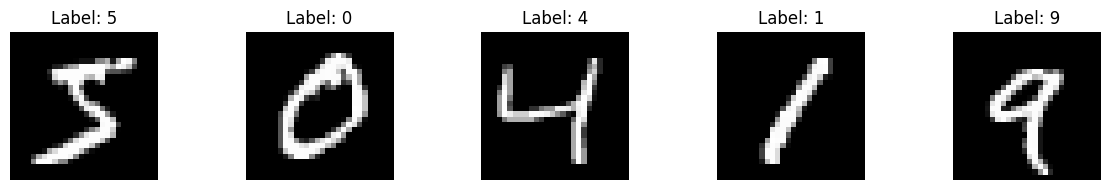

In [4]:
def show_mnist_samples(dataset, num_samples=5):
        fig, axes = plt.subplots(1, num_samples, figsize=(12, 2))
        for i in range(num_samples):
            img, label = dataset[i]
            axes[i].imshow(img.squeeze(), cmap='gray')
            axes[i].set_title(f'Label: {label}')
            axes[i].axis('off')
        plt.tight_layout()
        plt.show()
show_mnist_samples(train_dataset)

In [5]:

from models.tinyProp import TinyPropParams
visualizer = TinyMLVisualizer()

tinyprop_params = TinyPropParams(
    S_min=0.3,  
    S_max=0.9,  
    zeta=0.95,  
    number_of_layers=2  
)

   
os.makedirs('results', exist_ok=True)

In [6]:
from clients.aggregators import sparse_fedavg_aggregate
# First, let's create a function to run training for each partition
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Run training
    model, accuracy_list, flops_list, mem_list, comm_list, sparsity_list, \
    avg_grad_norm_list, avg_phi_list, skipped_batches_list, \
    effective_compute_ratio_list, client_eval_history, compression_ratio_list, \
    history = federated_training(
        client_datasets=client_datasets,
        model_name='mnist',
        testset=test_dataset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=10,
        early_stopping_delta=0.001,
        csv_log_path=f'results/mnist_{partition_name}_training_log.csv',
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000
    )
    
    return model, history

partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, history = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'history': history
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue



Starting training for DIRICHLET_IID partition...

Training on partition: DIRICHLET_IID

Round 1/100
Test Accuracy: 0.8800
[Compute] round_flops=2581888.80, [Mem] peak=6484479.698015704 bytes, [Comm] 25697907.200000003 bytes, [Sparsity] 1.21%
Round 1/100
Train Loss: 533.6244
Train Accuracy: 0.5363
Test Accuracy: 0.8800
Sparsity: 0.0121
Energy: 2.0600 J
Communication: 17782.91 KB
--------------------------------------------------

Round 2/100
Test Accuracy: 0.9782
[Compute] round_flops=2564282.61, [Mem] peak=6476482.850409566 bytes, [Comm] 25918556.8 bytes, [Sparsity] 0.37%
Round 2/100
Train Loss: 34.9187
Train Accuracy: 0.9707
Test Accuracy: 0.9782
Sparsity: 0.0037
Energy: 2.0600 J
Communication: 17782.91 KB
--------------------------------------------------

Round 3/100
Test Accuracy: 0.9837
[Compute] round_flops=2551180.93, [Mem] peak=6457140.849157311 bytes, [Comm] 25884035.200000003 bytes, [Sparsity] 0.50%
Round 3/100
Train Loss: 19.8367
Train Accuracy: 0.9840
Test Accuracy: 0.9837

Found IID results at results/mnist_dirichlet_iid_training_log.csv
Found Non-IID results at results/mnist_dirichlet_noniid_training_log.csv
Found Medium results at results/mnist_dirichlet_medium_training_log.csv


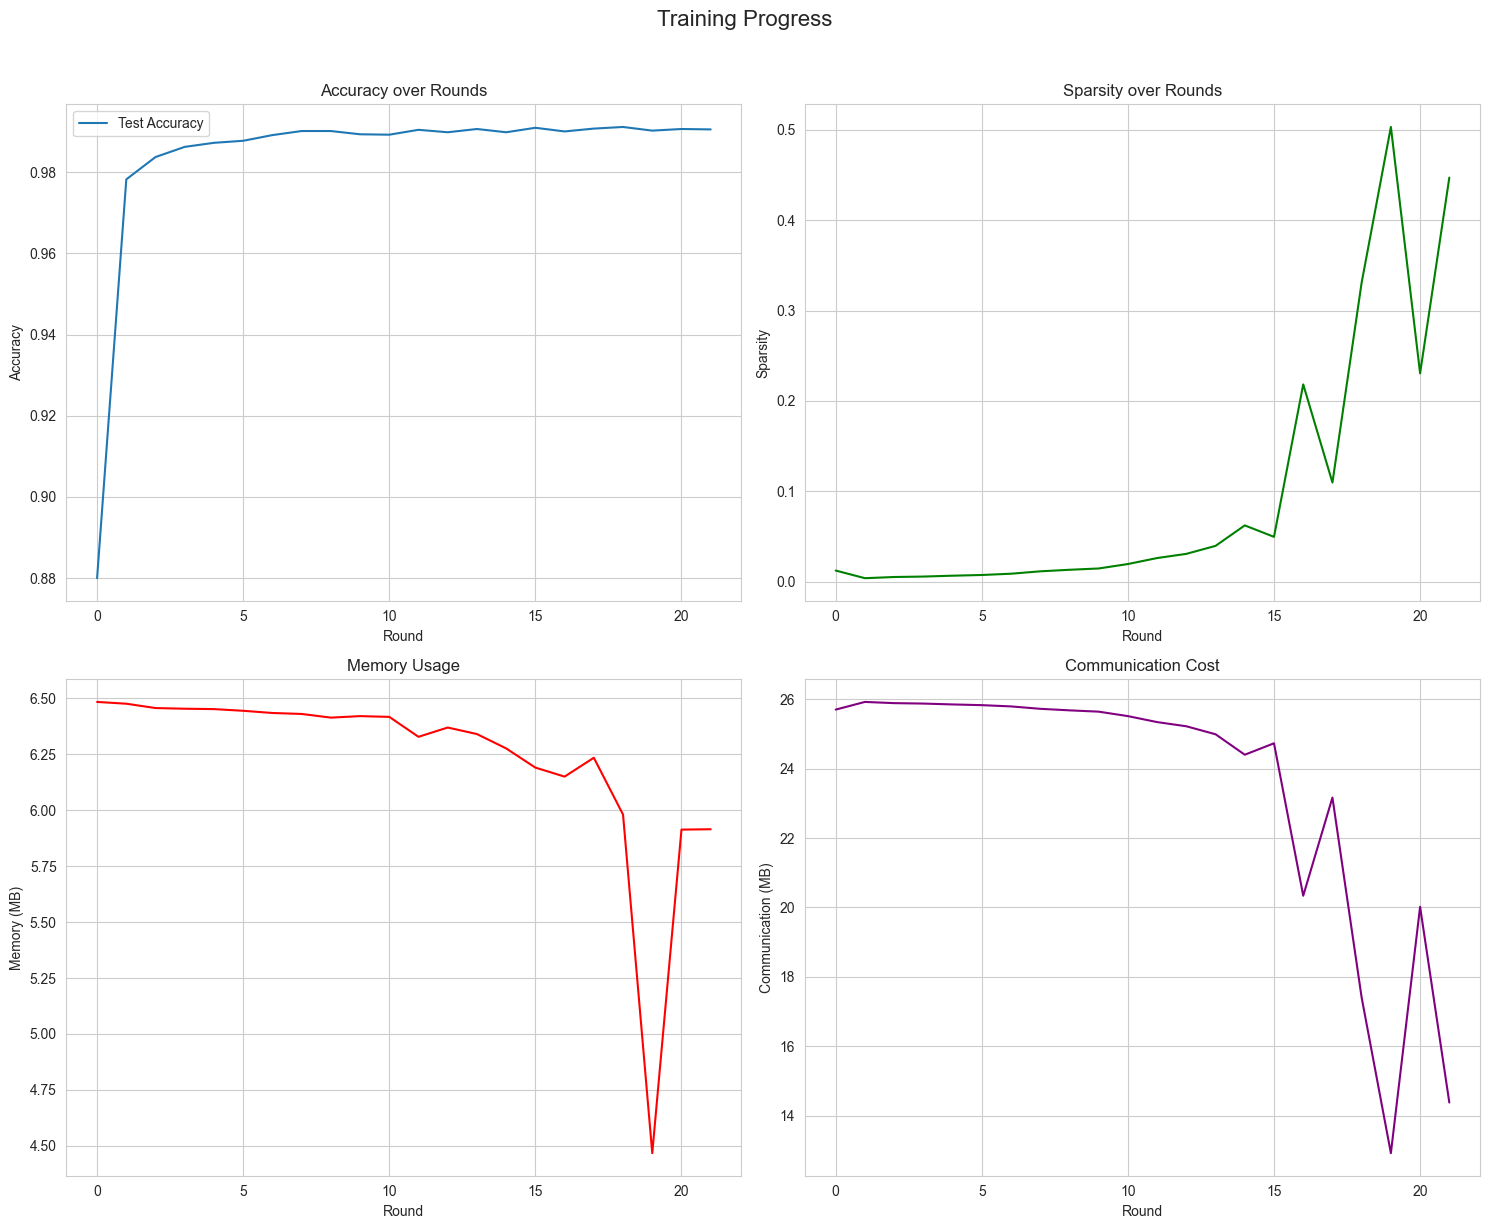

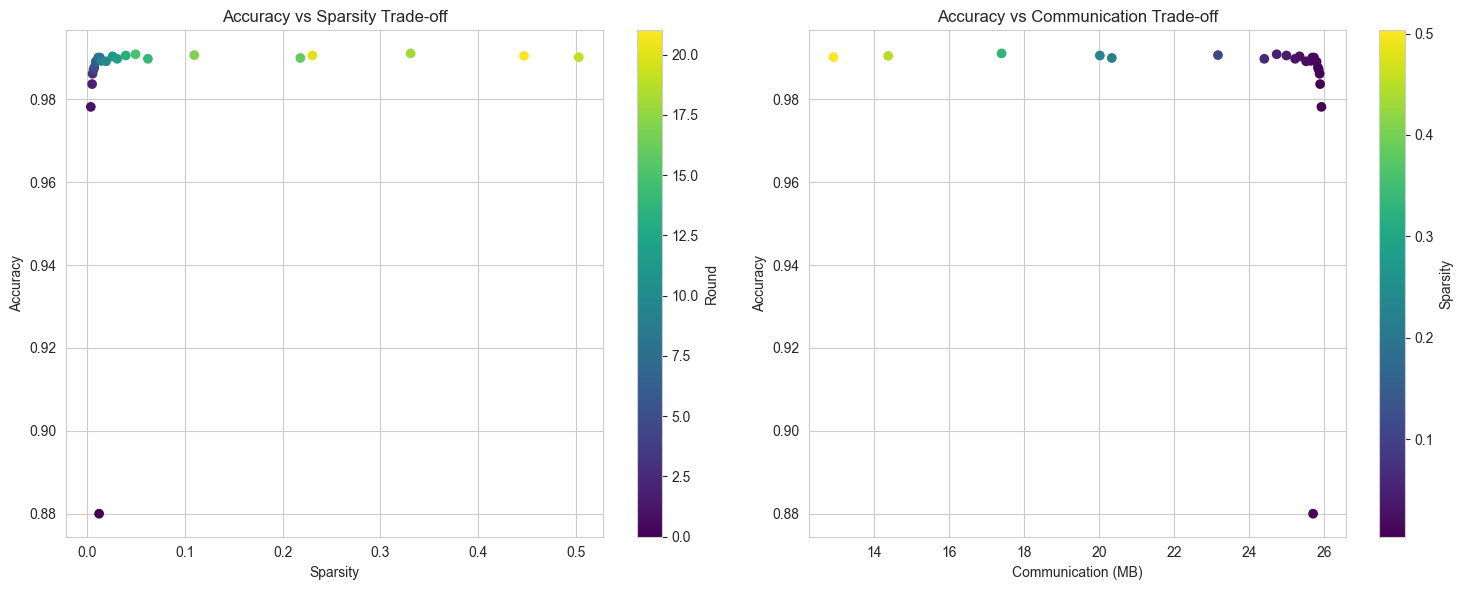

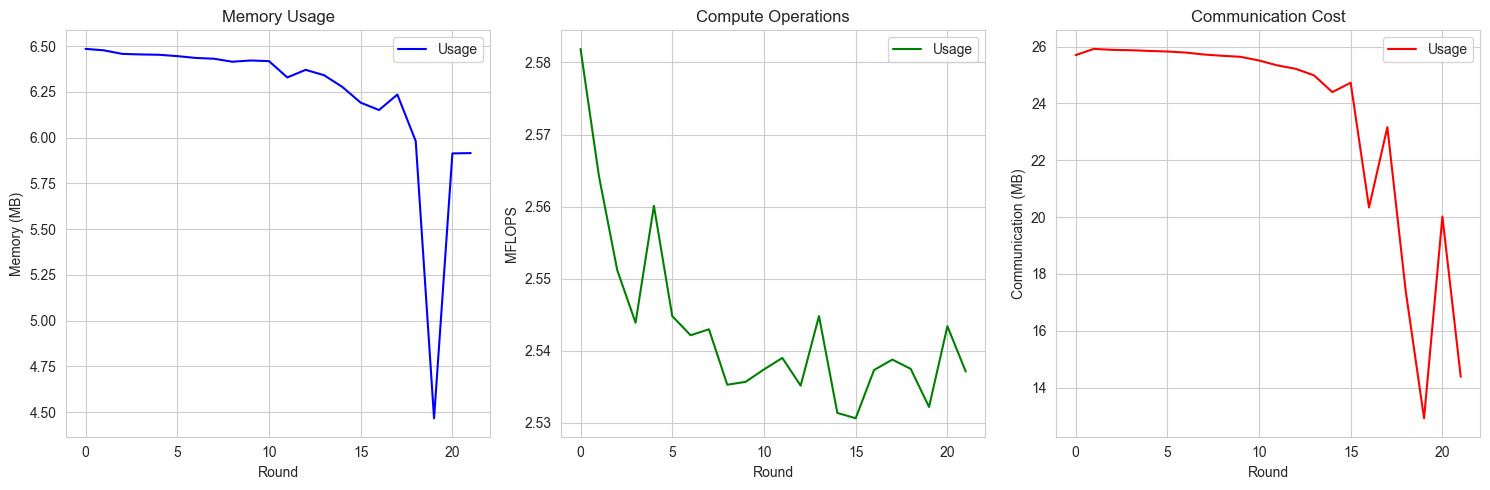

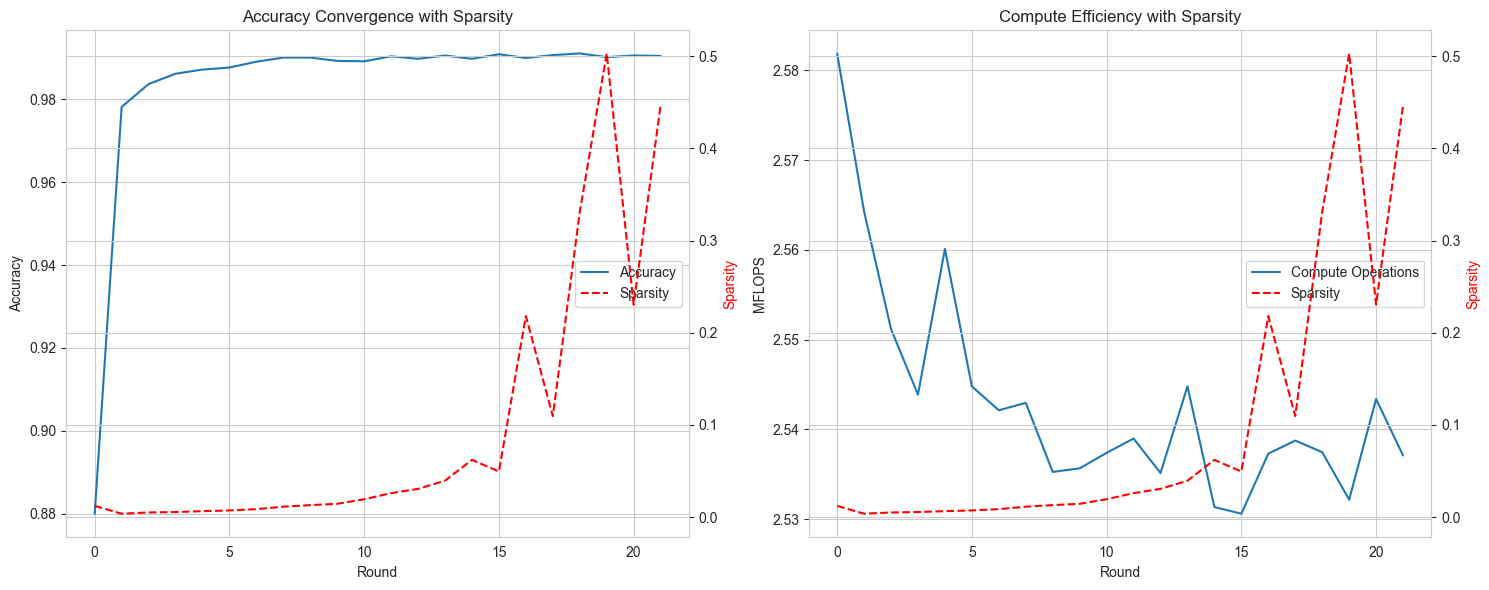

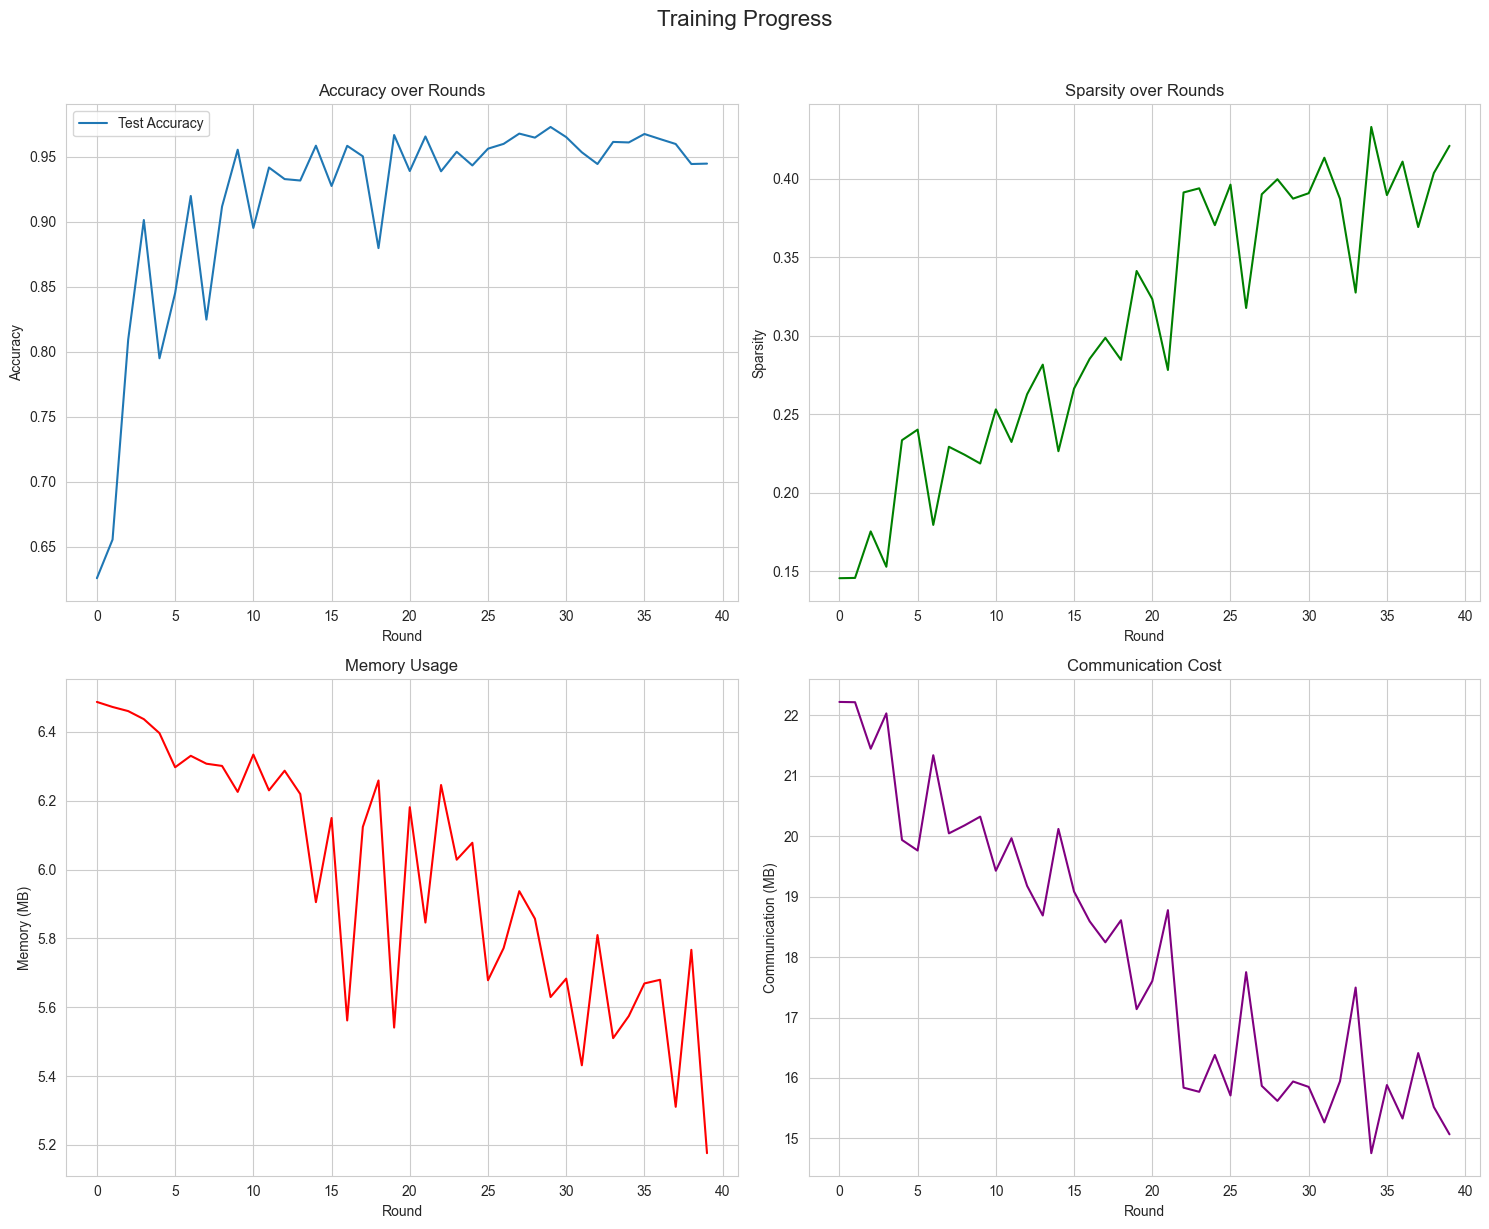

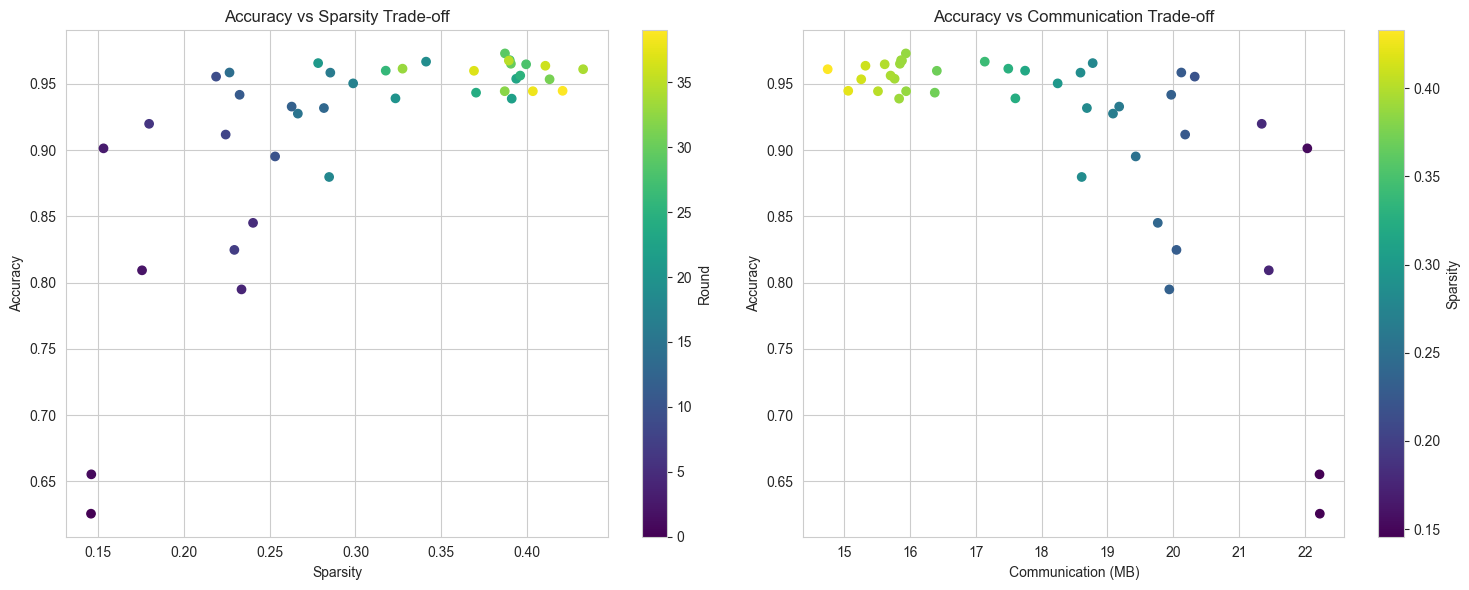

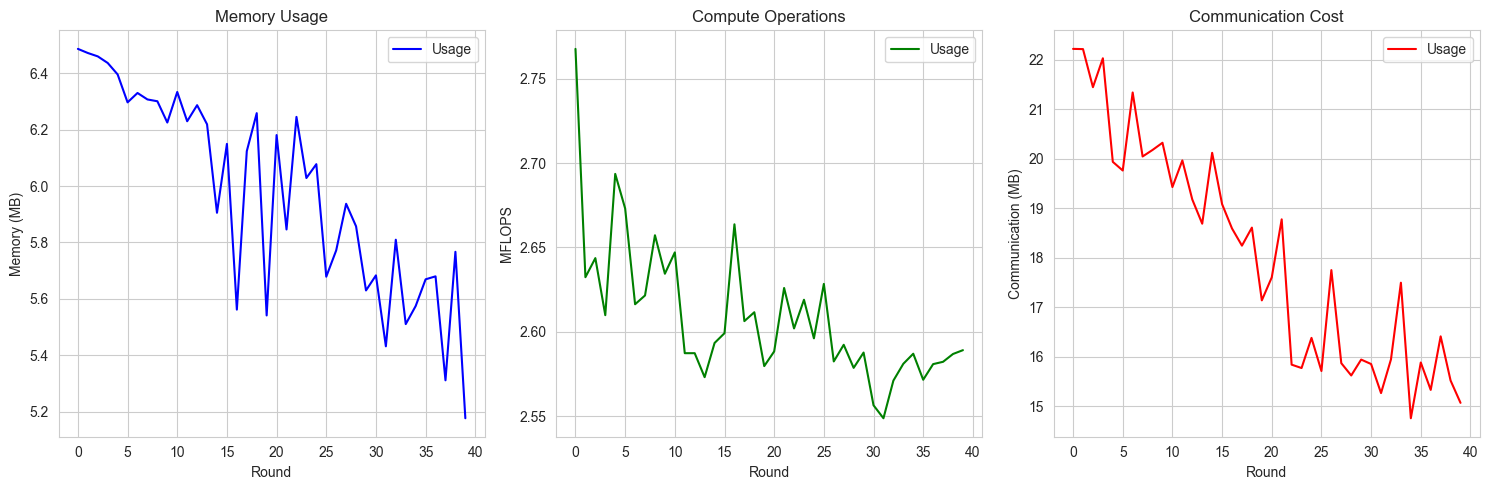

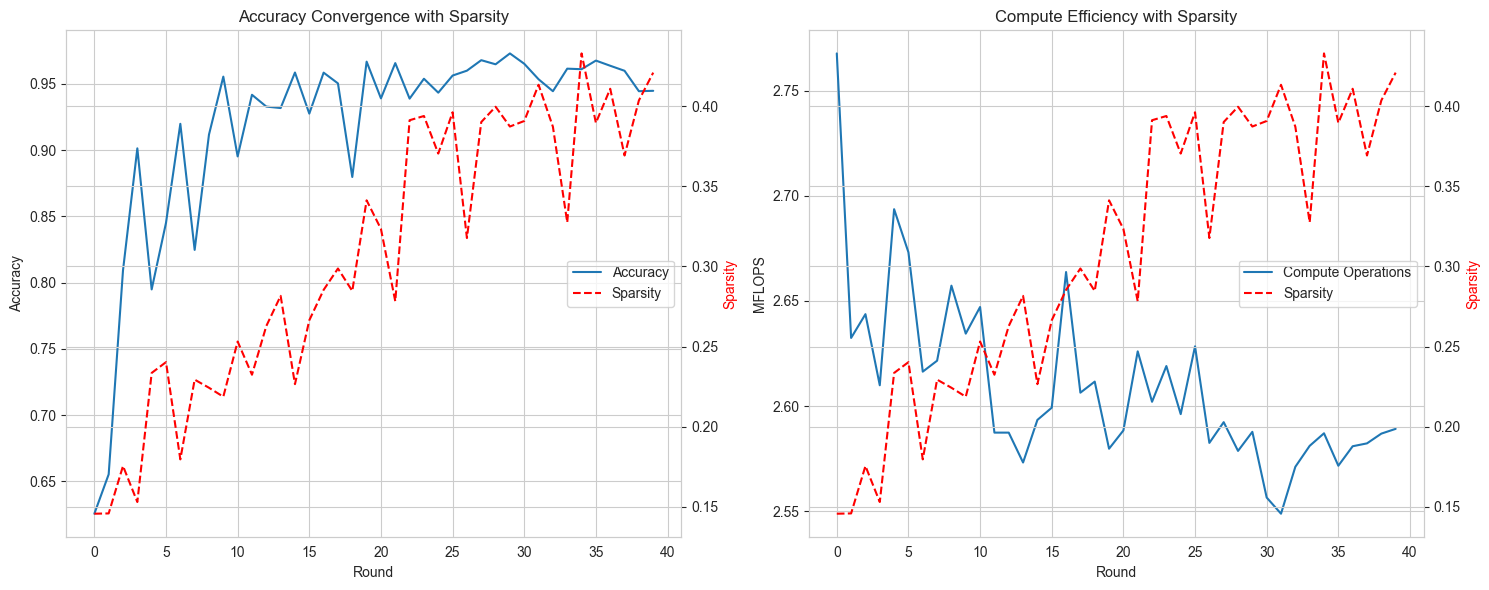

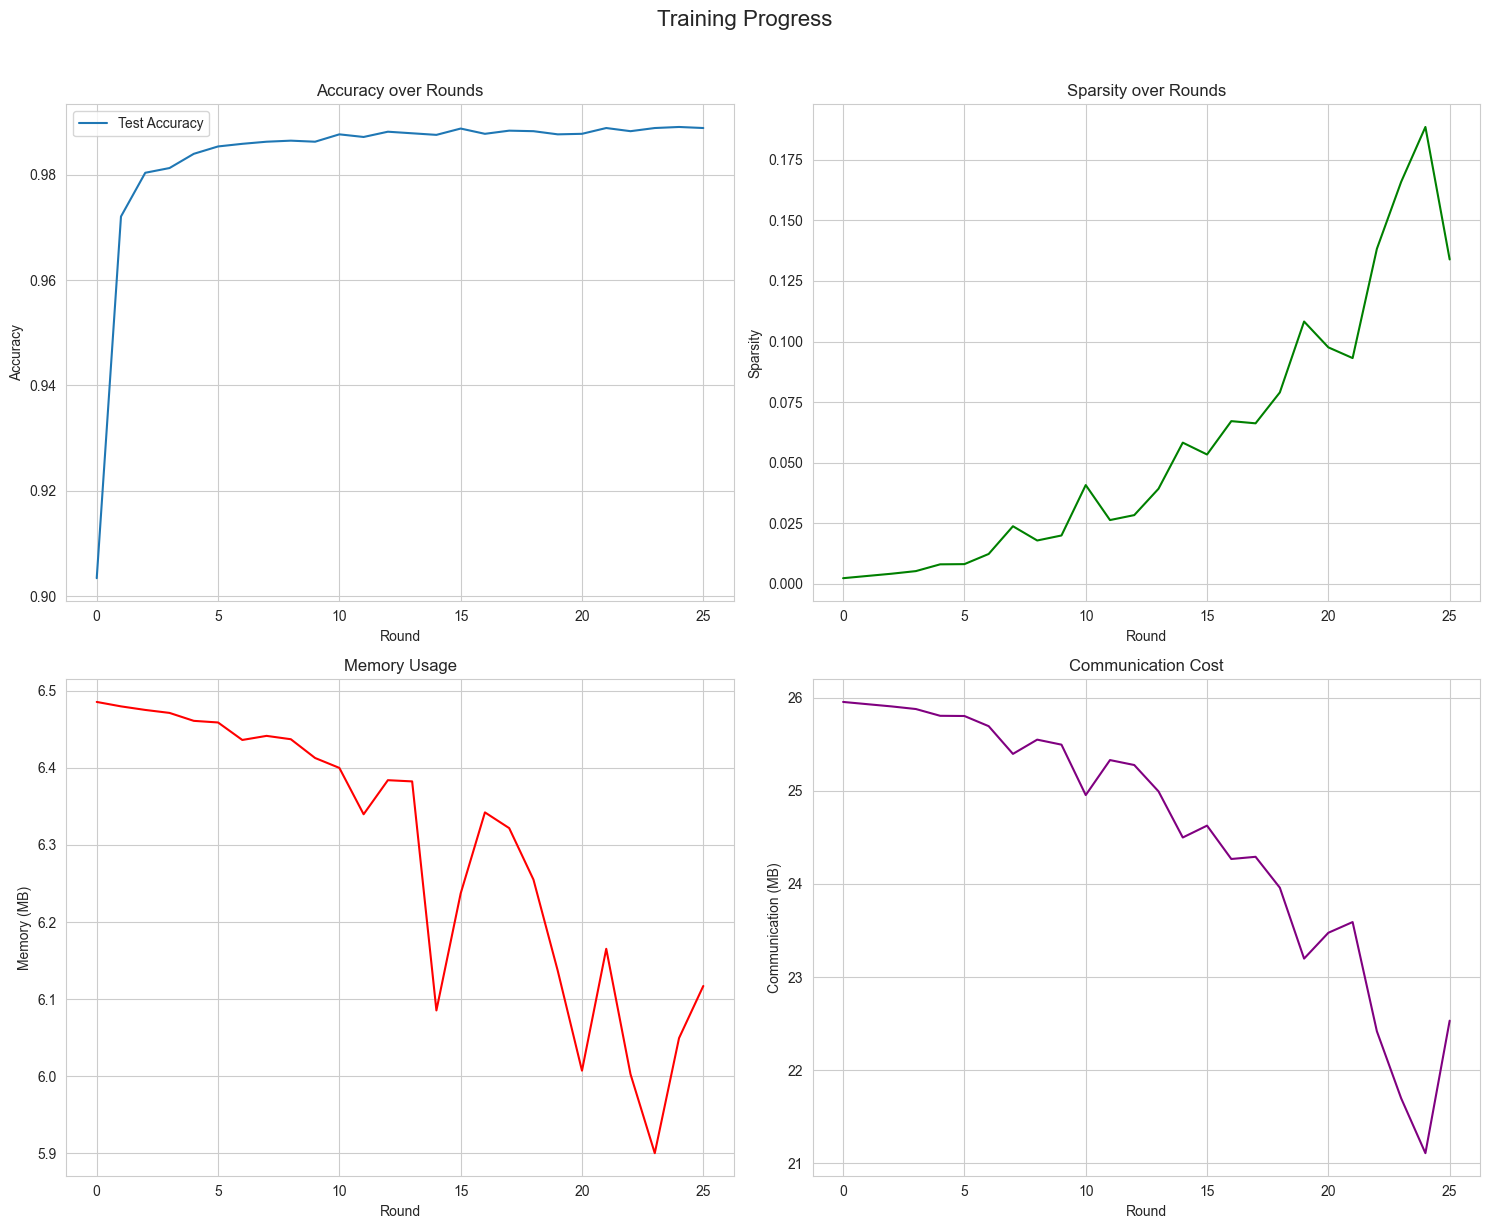

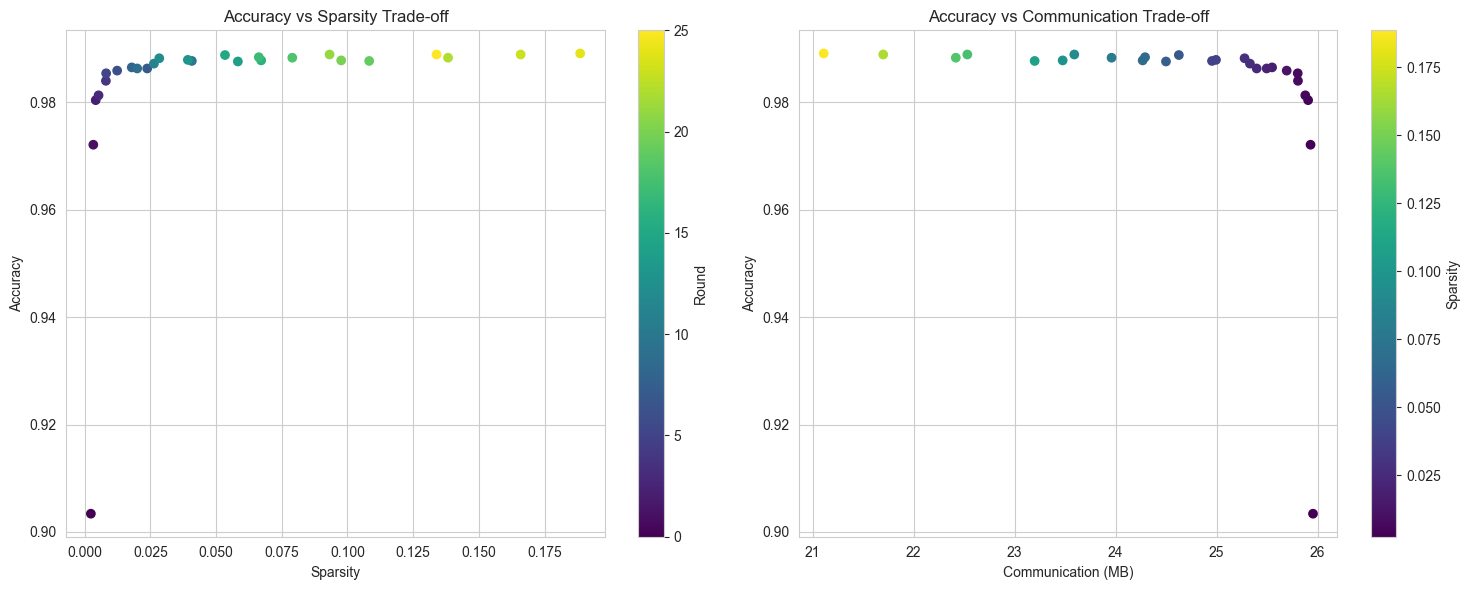

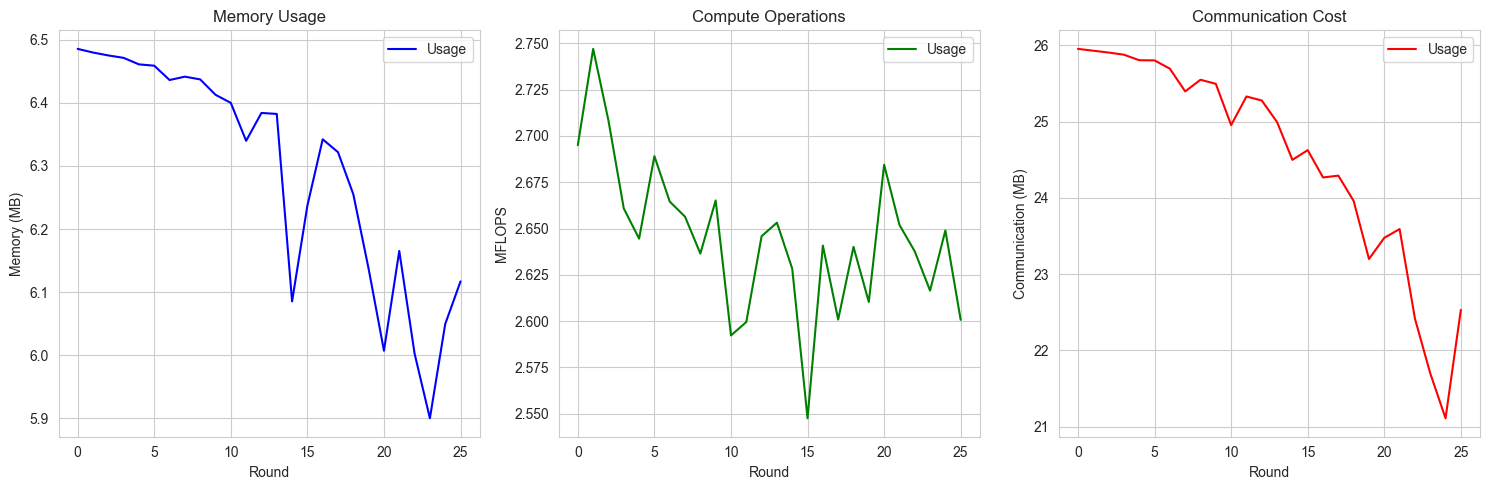

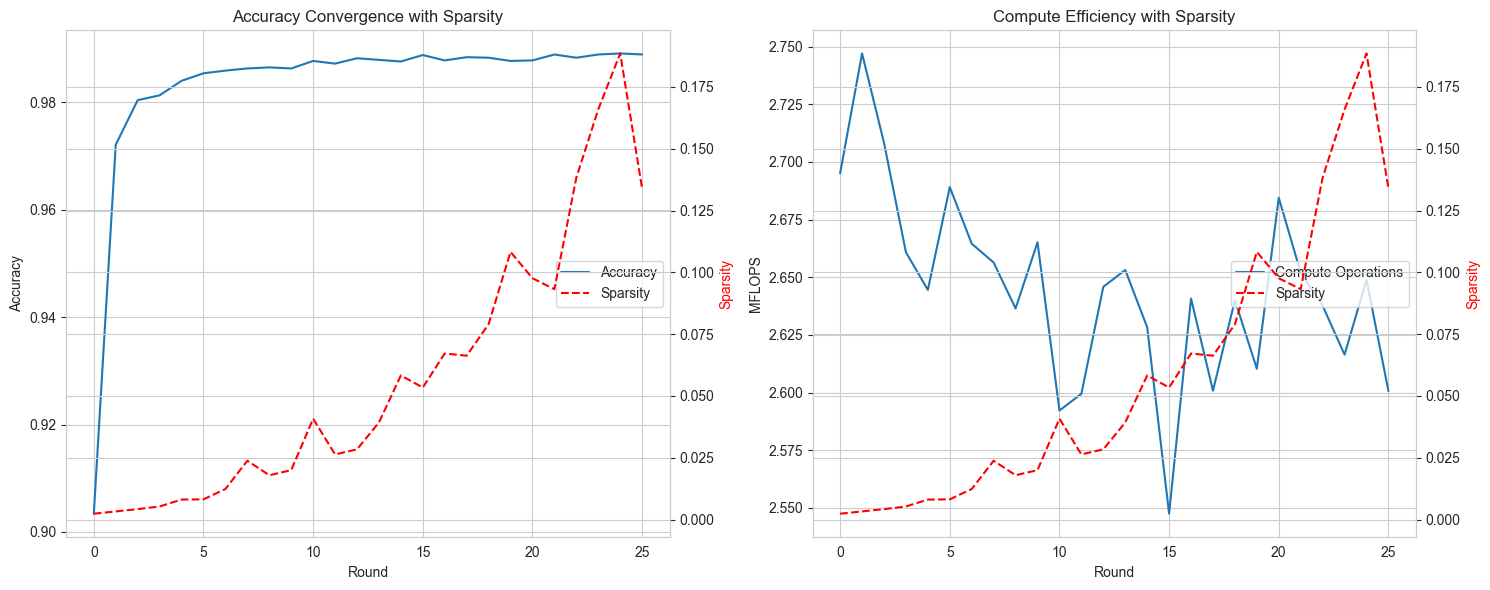


Summary Statistics:
         Final Accuracy  Max Accuracy  Average Memory (MB)  \
IID              0.9905        0.9911             6.229857   
Non-IID          0.9447        0.9729             5.979710   
Medium           0.9889        0.9891             6.295664   

         Average Communication (MB)  Average FLOPS (MFLOPS)  Final Sparsity  \
IID                       23.467233                2.543027        0.447127   
Non-IID                   18.033654                2.608867        0.420834   
Medium                    24.523320                2.644847        0.133877   

         Compression Ratio  Effective Compute Ratio  
IID               1.808733                 0.543282  
Non-IID           1.726621                 0.541809  
Medium            1.154571                 0.835779  


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.visualization import (
    plot_training_metrics,
    plot_efficiency_metrics,
    plot_hardware_profile,
    plot_convergence_analysis
)


csv_paths = {
    'IID': 'results/mnist_dirichlet_iid_training_log.csv',
    'Non-IID': 'results/mnist_dirichlet_noniid_training_log.csv',
    'Medium': 'results/mnist_dirichlet_medium_training_log.csv'
}

for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        print(f"Found {partition} results at {path}")
    except FileNotFoundError:
        print(f"Warning: Could not find {partition} results at {path}")

for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        history = {
            'accuracy': df['accuracy'].values,
            'sparsity': df['sparsity'].values,
            'memory_bytes': df['memory_bytes'].values,
            'communication_bytes': df['communication_bytes'].values,
            'flops': df['flops'].values
        }
        plot_training_metrics(history)
        plot_efficiency_metrics(history)
        plot_hardware_profile(history)
        plot_convergence_analysis(history)
    except Exception as e:
        print(f"Error plotting {partition} results: {e}")


summary_stats = {}
for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        summary_stats[partition] = {
            'Final Accuracy': df['accuracy'].iloc[-1],
            'Max Accuracy': df['accuracy'].max(),
            'Average Memory (MB)': df['memory_bytes'].mean() / 1e6,
            'Average Communication (MB)': df['communication_bytes'].mean() / 1e6,
            'Average FLOPS (MFLOPS)': df['flops'].mean() / 1e6,
            'Final Sparsity': df['sparsity'].iloc[-1],
            'Compression Ratio': 1 / (1 - df['sparsity'].iloc[-1]),
            'Effective Compute Ratio': (1 - df['sparsity'].iloc[-1]) * df['flops'].iloc[-1] / df['flops'].iloc[0]
        }
    except Exception as e:
        print(f"Error calculating statistics for {partition}: {e}")

summary_df = pd.DataFrame(summary_stats).T
print("\nSummary Statistics:")
print(summary_df)